In [ ]:
!pip install kaggle


In [ ]:
from google.colab import files
files.upload()  # This will prompt you to upload the kaggle.json file

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"shaba2643","key":"fe083efdd3794236a5f25fe6c2559944"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c cifar-10

100% 714M/715M [00:10<00:00, 17.3MB/s]
100% 715M/715M [00:10<00:00, 72.5MB/s]


In [ ]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.preprocessing import StandardScaler

# Define transformations for the training and test sets with augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

classes = trainset.classes  # CIFAR-10 has 10 classes

# Define a ResNet-based model
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, temperature=1.0):
        super(ResNetFeatureExtractor, self).__init__()
        self.temperature = temperature
        self.base_model = models.resnet18(pretrained=True)
        self.base_model.fc = nn.Linear(self.base_model.fc.in_features, 10)  # Adjust for CIFAR-10 classes

    def forward(self, x):
        x = self.base_model(x)
        x = x / self.temperature  # Apply temperature scaling
        return x

# Initialize the teacher model
teacher_net = ResNetFeatureExtractor(temperature=10.0).to("cuda")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(teacher_net.parameters(), lr=0.0005, weight_decay=5e-4)

# Train the teacher model
epochs = 20
for epoch in range(epochs):
    teacher_net.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to("cuda"), data[1].to("cuda")
        optimizer.zero_grad()
        outputs = teacher_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(trainloader):.4f}')

print('Finished Training Teacher Model')

# Generate soft labels using the trained teacher model
def generate_soft_labels(model, dataloader):
    model.eval()
    soft_labels = []
    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.to("cuda")
            outputs = model(inputs)
            soft_labels.append(F.softmax(outputs / 10.0, dim=1).cpu().numpy())  # Temperature during training
    return np.concatenate(soft_labels)

train_soft_labels = generate_soft_labels(teacher_net, trainloader)

# Initialize the student model
student_net = ResNetFeatureExtractor(temperature=1.0).to("cuda")
optimizer = optim.Adam(student_net.parameters(), lr=0.0005, weight_decay=5e-4)

# Custom loss function to incorporate soft labels
def distillation_loss(y, labels, teacher_scores, T, alpha=0.5):
    return nn.KLDivLoss()(F.log_softmax(y / T, dim=1), F.softmax(teacher_scores / T, dim=1)) * (T * T * alpha) + \
           F.cross_entropy(y, labels) * (1. - alpha)

# Train the student model
for epoch in range(epochs):
    student_net.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to("cuda"), data[1].to("cuda")
        teacher_outputs = teacher_net(inputs)
        optimizer.zero_grad()
        student_outputs = student_net(inputs)
        loss = distillation_loss(student_outputs, labels, teacher_outputs, T=10.0, alpha=0.7)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(trainloader):.4f}')

print('Finished Training Student Model')

# Extract features from the model
def extract_features(model, dataloader):
    features = []
    labels = []
    model.eval()
    with torch.no_grad():
        for data in dataloader:
            images, targets = data[0].to("cuda"), data[1].to("cuda")
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels.append(targets.cpu().numpy())
    return np.concatenate(features), np.concatenate(labels)

train_features, train_labels = extract_features(student_net, trainloader)
test_features, test_labels = extract_features(student_net, testloader)

# Normalize features
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# Train classifiers
svm_clf = SVC(probability=True)
svm_clf.fit(train_features, train_labels)

nb_clf = GaussianNB()
nb_clf.fit(train_features, train_labels)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(train_features, train_labels)

dt_clf = DecisionTreeClassifier(max_depth=10)
dt_clf.fit(train_features, train_labels)

ensemble_clf = VotingClassifier(estimators=[
    ('svm', svm_clf), ('nb', nb_clf), ('knn', knn_clf), ('dt', dt_clf)], voting='soft')
ensemble_clf.fit(train_features, train_labels)

# Evaluate classifiers
def evaluate_model(clf, test_features, test_labels, name):
    preds = clf.predict(test_features)
    acc = accuracy_score(test_labels, preds)
    print(f'{name} Accuracy: {acc * 100:.2f}%')
    return acc

evaluate_model(svm_clf, test_features, test_labels, 'SVM')
evaluate_model(nb_clf, test_features, test_labels, 'Naive Bayes')
evaluate_model(knn_clf, test_features, test_labels, 'k-NN')
evaluate_model(dt_clf, test_features, test_labels, 'Decision Tree')
evaluate_model(ensemble_clf, test_features, test_labels, 'Ensemble')


Files already downloaded and verified
Files already downloaded and verified


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


Epoch 1/20, Loss: 1.1745
Epoch 2/20, Loss: 0.9073
Epoch 3/20, Loss: 0.8213
Epoch 4/20, Loss: 0.7813
Epoch 5/20, Loss: 0.7432
Epoch 6/20, Loss: 0.7152
Epoch 7/20, Loss: 0.6947
Epoch 8/20, Loss: 0.6774
Epoch 9/20, Loss: 0.6642
Epoch 10/20, Loss: 0.6521
Epoch 11/20, Loss: 0.6405
Epoch 12/20, Loss: 0.6226
Epoch 13/20, Loss: 0.6187
Epoch 14/20, Loss: 0.6131
Epoch 15/20, Loss: 0.6072
Epoch 16/20, Loss: 0.5934
Epoch 17/20, Loss: 0.5940
Epoch 18/20, Loss: 0.5883
Epoch 19/20, Loss: 0.5838
Epoch 20/20, Loss: 0.5804
Finished Training Teacher Model


/usr/local/lib/python3.10/dist-packages/torch/nn/functional.py:3369: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Epoch 1/20, Loss: 0.4008
Epoch 2/20, Loss: 0.3076
Epoch 3/20, Loss: 0.2839
Epoch 4/20, Loss: 0.2725
Epoch 5/20, Loss: 0.2627
Epoch 6/20, Loss: 0.2550
Epoch 7/20, Loss: 0.2491
Epoch 8/20, Loss: 0.2450
Epoch 9/20, Loss: 0.2390
Epoch 10/20, Loss: 0.2355
Epoch 11/20, Loss: 0.2336
Epoch 12/20, Loss: 0.2291
Epoch 13/20, Loss: 0.2276
Epoch 14/20, Loss: 0.2271
Epoch 15/20, Loss: 0.2256
Epoch 16/20, Loss: 0.2217
Epoch 17/20, Loss: 0.2209
Epoch 18/20, Loss: 0.2209
Epoch 19/20, Loss: 0.2194
Epoch 20/20, Loss: 0.2189
Finished Training Student Model
SVM Accuracy: 81.60%
Naive Bayes Accuracy: 79.69%
k-NN Accuracy: 80.00%
Decision Tree Accuracy: 78.61%
Ensemble Accuracy: 81.20%


0.812

In [ ]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.preprocessing import StandardScaler

# Define transformations for the training and test sets with augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Fixed std parameter
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Fixed std parameter
])

# Load the CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

classes = trainset.classes  # CIFAR-10 has 10 classes

# Define a ResNet-based model
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, temperature=1.0):
        super(ResNetFeatureExtractor, self).__init__()
        self.temperature = temperature
        self.base_model = models.resnet18(pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])  # Extract up to the second last layer
        self.fc = nn.Linear(self.base_model.fc.in_features, 10)

    def forward(self, x, return_features=False):
        x = self.features(x)
        x = torch.flatten(x, 1)
        if return_features:
            return x  # Return intermediate features for attack
        x = self.fc(x) / self.temperature
        return x

# Initialize the teacher model
teacher_net = ResNetFeatureExtractor(temperature=10.0).to("cuda")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(teacher_net.parameters(), lr=0.0005, weight_decay=5e-4)

# Train the teacher model
epochs = 20
for epoch in range(epochs):
    teacher_net.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to("cuda"), data[1].to("cuda")
        optimizer.zero_grad()
        outputs = teacher_net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(trainloader):.4f}')

print('Finished Training Teacher Model')

# Generate soft labels using the trained teacher model
def generate_soft_labels(model, dataloader):
    model.eval()
    soft_labels = []
    with torch.no_grad():
        for inputs, _ in dataloader:
            inputs = inputs.to("cuda")
            outputs = model(inputs)
            soft_labels.append(F.softmax(outputs / 10.0, dim=1).cpu().numpy())  # Temperature during training
    return np.concatenate(soft_labels)

train_soft_labels = generate_soft_labels(teacher_net, trainloader)

# Initialize the student model
student_net = ResNetFeatureExtractor(temperature=1.0).to("cuda")
optimizer = optim.Adam(student_net.parameters(), lr=0.0005, weight_decay=5e-4)

# Custom loss function to incorporate soft labels
def distillation_loss(y, labels, teacher_scores, T, alpha=0.5):
    return nn.KLDivLoss()(F.log_softmax(y / T, dim=1), F.softmax(teacher_scores / T, dim=1)) * (T * T * alpha) + \
           F.cross_entropy(y, labels) * (1. - alpha)

# Train the student model
for epoch in range(epochs):
    student_net.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to("cuda"), data[1].to("cuda")
        teacher_outputs = teacher_net(inputs)
        optimizer.zero_grad()
        student_outputs = student_net(inputs)
        loss = distillation_loss(student_outputs, labels, teacher_outputs, T=10.0, alpha=0.7)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(trainloader):.4f}')

print('Finished Training Student Model')

# Extract features from the model
def extract_features(model, dataloader):
    features = []
    labels = []
    model.eval()
    with torch.no_grad():
        for data in dataloader:
            images, targets = data[0].to("cuda"), data[1].to("cuda")
            outputs = model(images, return_features=True)
            features.append(outputs.cpu().numpy())
            labels.append(targets.cpu().numpy())
    return np.concatenate(features), np.concatenate(labels)

train_features, train_labels = extract_features(student_net, trainloader)
test_features, test_labels = extract_features(student_net, testloader)

# Normalize features
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# Train classifiers
svm_clf = SVC(probability=True)
svm_clf.fit(train_features, train_labels)

nb_clf = GaussianNB()
nb_clf.fit(train_features, train_labels)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(train_features, train_labels)

dt_clf = DecisionTreeClassifier(max_depth=10)
dt_clf.fit(train_features, train_labels)

ensemble_clf = VotingClassifier(estimators=[
    ('svm', svm_clf), ('nb', nb_clf), ('knn', knn_clf), ('dt', dt_clf)], voting='soft')
ensemble_clf.fit(train_features, train_labels)

# Evaluate classifiers
def evaluate_model(clf, test_features, test_labels, name):
    preds = clf.predict(test_features)
    acc = accuracy_score(test_labels, preds)
    print(f'{name} Accuracy: {acc * 100:.2f}%')
    return acc

print("\nEvaluating on Original Features:")
evaluate_model(svm_clf, test_features, test_labels, 'SVM')
evaluate_model(nb_clf, test_features, test_labels, 'Naive Bayes')
evaluate_model(knn_clf, test_features, test_labels, 'k-NN')
evaluate_model(dt_clf, test_features, test_labels, 'Decision Tree')
evaluate_model(ensemble_clf, test_features, test_labels, 'Ensemble')


100%|██████████| 170M/170M [00:04<00:00, 40.9MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 40.4MB/s]


Epoch 1/20, Loss: 1.1808
Epoch 2/20, Loss: 0.9049
Epoch 3/20, Loss: 0.8276
Epoch 4/20, Loss: 0.7774
Epoch 5/20, Loss: 0.7421
Epoch 6/20, Loss: 0.7205
Epoch 7/20, Loss: 0.7000
Epoch 8/20, Loss: 0.6802
Epoch 9/20, Loss: 0.6563
Epoch 10/20, Loss: 0.6502
Epoch 11/20, Loss: 0.6413
Epoch 12/20, Loss: 0.6332
Epoch 13/20, Loss: 0.6230
Epoch 14/20, Loss: 0.6157
Epoch 15/20, Loss: 0.6029
Epoch 16/20, Loss: 0.5972
Epoch 17/20, Loss: 0.5938
Epoch 18/20, Loss: 0.5922
Epoch 19/20, Loss: 0.5850
Epoch 20/20, Loss: 0.5802
Finished Training Teacher Model


/usr/local/lib/python3.10/dist-packages/torch/nn/functional.py:3369: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Epoch 1/20, Loss: 0.3967
Epoch 2/20, Loss: 0.3064
Epoch 3/20, Loss: 0.2851
Epoch 4/20, Loss: 0.2725
Epoch 5/20, Loss: 0.2648
Epoch 6/20, Loss: 0.2568
Epoch 7/20, Loss: 0.2505
Epoch 8/20, Loss: 0.2455
Epoch 9/20, Loss: 0.2423
Epoch 10/20, Loss: 0.2395
Epoch 11/20, Loss: 0.2345
Epoch 12/20, Loss: 0.2326
Epoch 13/20, Loss: 0.2290
Epoch 14/20, Loss: 0.2269
Epoch 15/20, Loss: 0.2254
Epoch 16/20, Loss: 0.2247
Epoch 17/20, Loss: 0.2214
Epoch 18/20, Loss: 0.2222
Epoch 19/20, Loss: 0.2210
Epoch 20/20, Loss: 0.2193
Finished Training Student Model

Evaluating on Original Features:
SVM Accuracy: 81.96%
Naive Bayes Accuracy: 81.18%
k-NN Accuracy: 80.24%
Decision Tree Accuracy: 79.51%
Ensemble Accuracy: 81.68%


0.8168

100%|██████████| 170M/170M [00:28<00:00, 6.05MB/s]


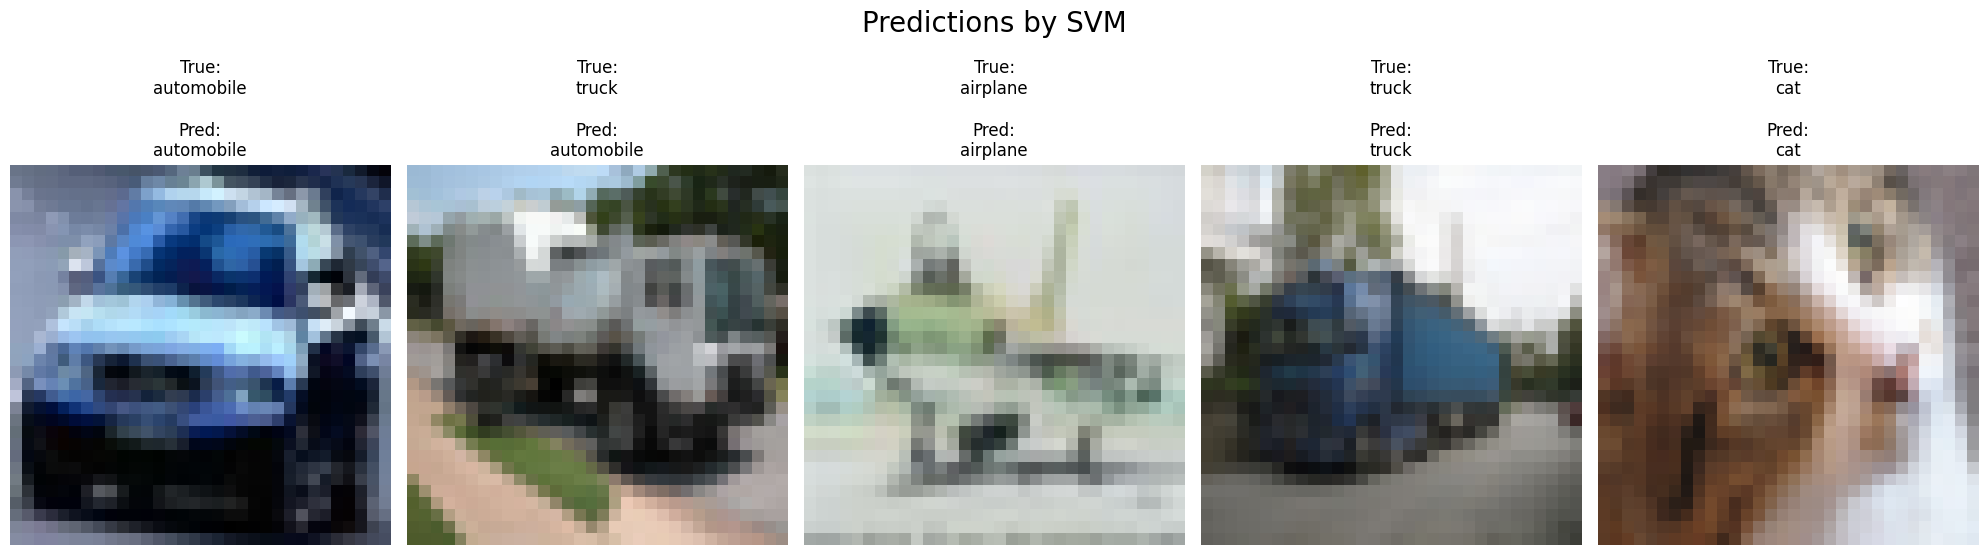

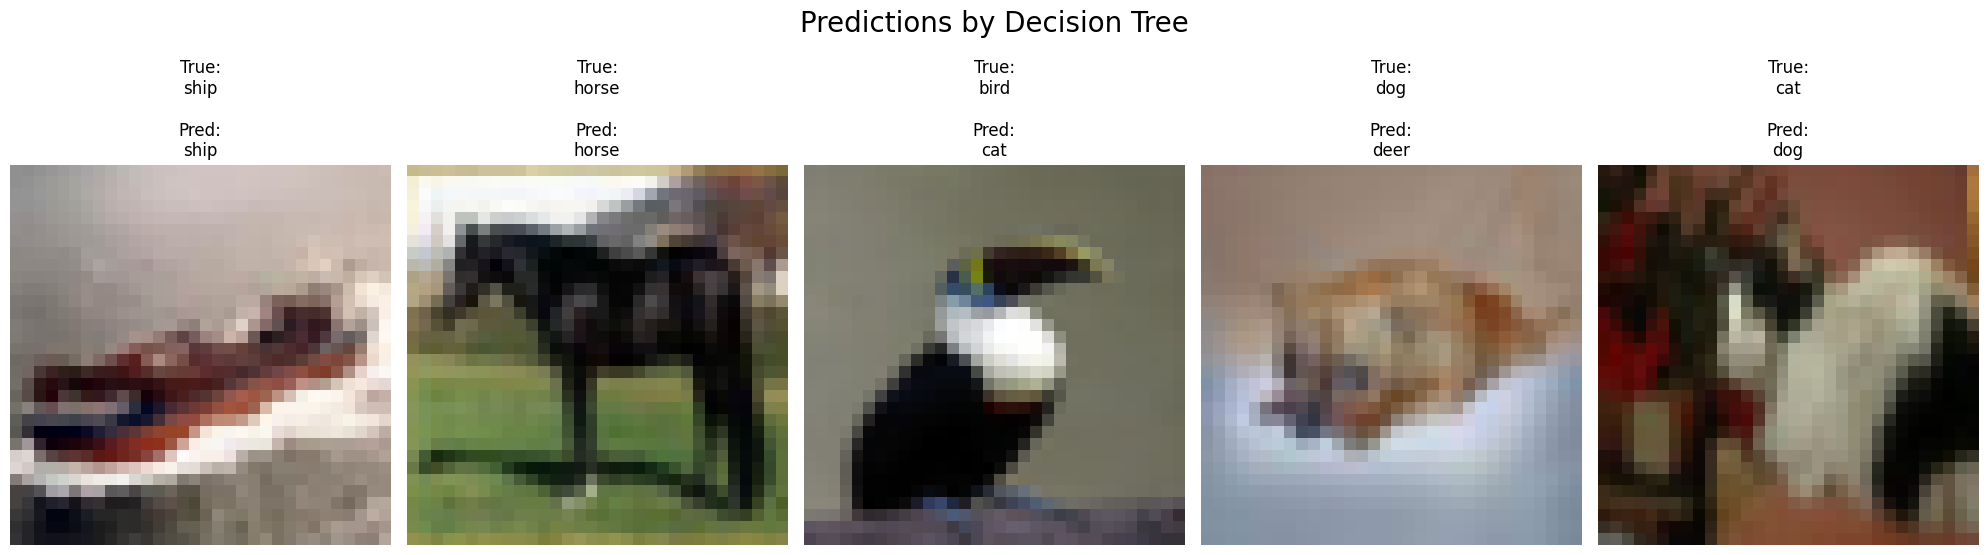

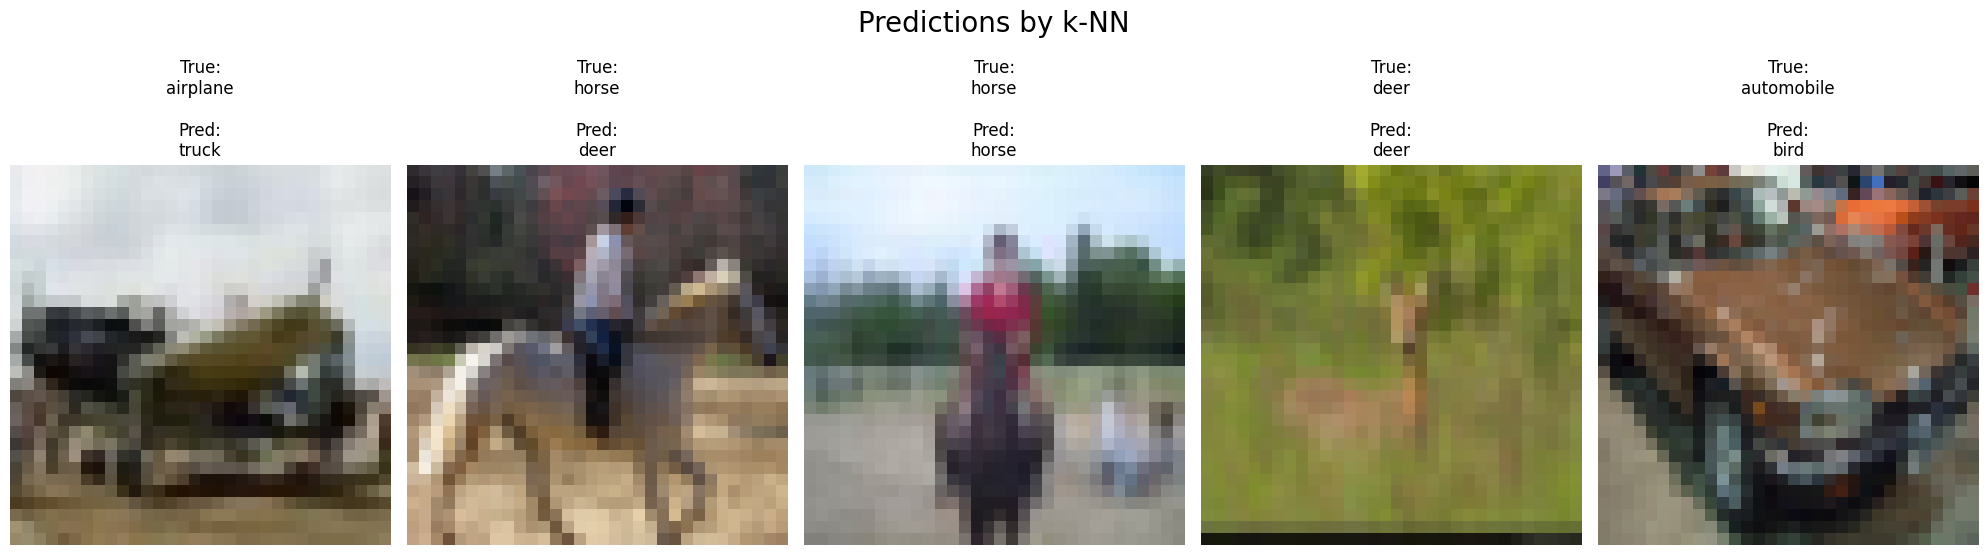

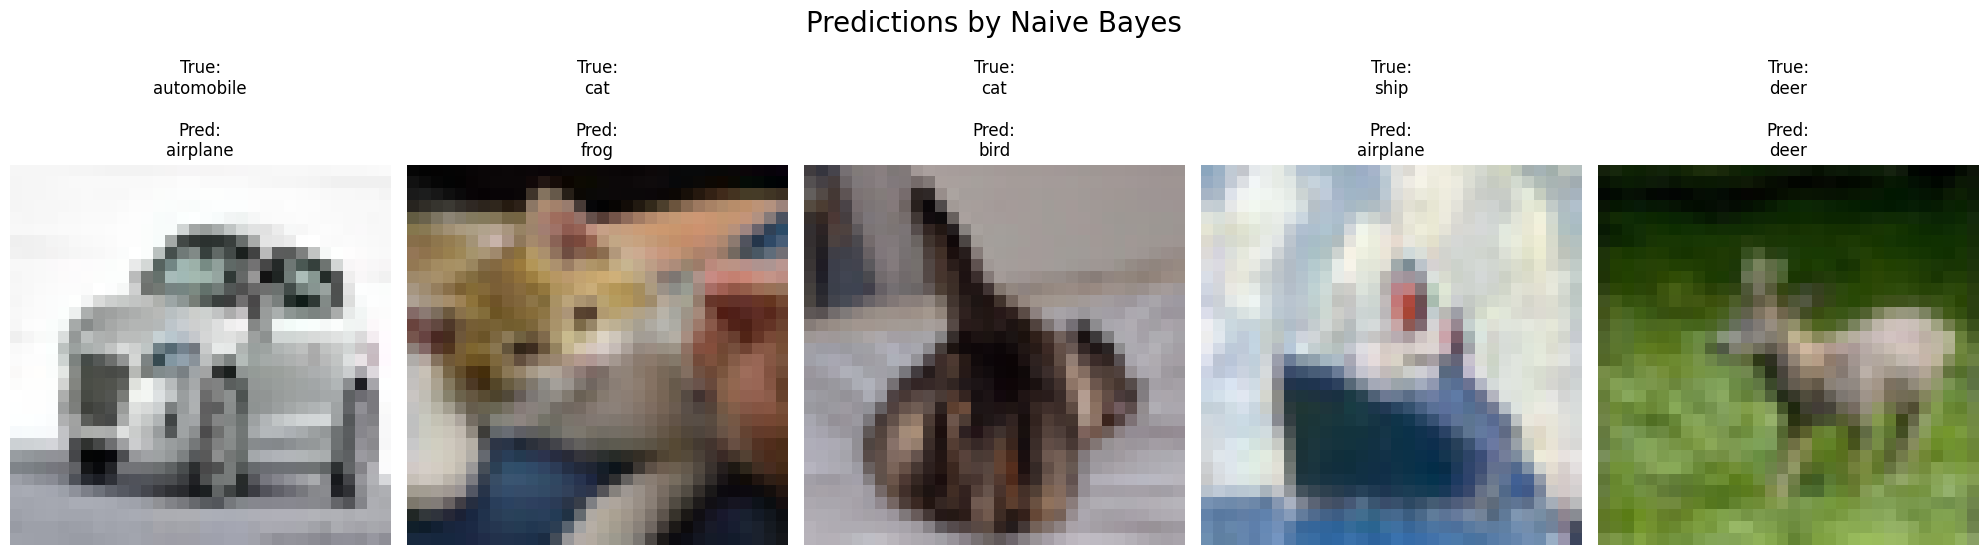

In [1]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
import numpy as np
import random

# Step 1: Load the CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# CIFAR-10 classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Step 2: Prepare images and labels
train_images = train_dataset.data  # shape (50000, 32, 32, 3)
train_labels = np.array(train_dataset.targets)
test_images = test_dataset.data  # shape (10000, 32, 32, 3)
test_labels = np.array(test_dataset.targets)

# Step 3: Flatten images
train_images_flat = train_images.reshape(len(train_images), -1)
test_images_flat = test_images.reshape(len(test_images), -1)

# Step 4: Normalize
scaler = StandardScaler()
train_images_flat = scaler.fit_transform(train_images_flat)
test_images_flat = scaler.transform(test_images_flat)

# Step 5: Train classifiers on a smaller subset to speed up
subset_indices = np.random.choice(len(train_images_flat), 5000, replace=False)
train_images_flat_small = train_images_flat[subset_indices]
train_labels_small = train_labels[subset_indices]

svm_clf = SVC()
svm_clf.fit(train_images_flat_small, train_labels_small)

dt_clf = DecisionTreeClassifier()
dt_clf.fit(train_images_flat_small, train_labels_small)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(train_images_flat_small, train_labels_small)

nb_clf = GaussianNB()
nb_clf.fit(train_images_flat_small, train_labels_small)

# Step 6: Predict
svm_preds = svm_clf.predict(test_images_flat)
dt_preds = dt_clf.predict(test_images_flat)
knn_preds = knn_clf.predict(test_images_flat)
nb_preds = nb_clf.predict(test_images_flat)

# Step 7: Show results for each classifier
def plot_predictions(predictions, classifier_name):
    indices = random.sample(range(len(test_dataset)), 5)  # 5 random images
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f'Predictions by {classifier_name}', fontsize=20, y=1.1)

    for i, idx in enumerate(indices):
        img = test_images[idx]
        true_label = classes[test_labels[idx]]
        pred_label = classes[predictions[idx]]

        axes[i].imshow(img)
        axes[i].set_title(f'True:\n{true_label}\n\nPred:\n{pred_label}', fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Plot for each classifier
plot_predictions(svm_preds, "SVM")
plot_predictions(dt_preds, "Decision Tree")
plot_predictions(knn_preds, "k-NN")
plot_predictions(nb_preds, "Naive Bayes")
